# Comparing the multi-scale FHRR models against the numpy VSA baseline

`scripts/visualize_vsa_baseline.py` sweeps `VSASpatialMemory`
(`models/baseline.py`) over several fixed length scales, at `ssp_dim=4096`.
This notebook compares that baseline against the models developed in
`multi_scale_learning.ipynb` (multi-scale mixture, per-class memory,
temperature calibration), fairly:

- **Same vector dimensionality (1024)** for every model.
- **Same length scale (0.1)** for the baseline (it has no multi-scale
  mixture); our models keep their learned coarse/medium/fine mixture, so the
  comparison reflects the whole approach, not just a single-scale swap.
- **Same train/val split, same data, same random seed** for every model.
- **Same memory *structure*** compared against itself: a shared global
  vector baseline against our shared-vector model, and a separate one-memory
  -per-class baseline (`PerClassVSASpatialMemory`, added to
  `models/baseline.py` for this comparison) against our per-class-memory
  model. Never shared vs. per-class across approaches.
- **Same temperature-calibration procedure** (sweep against validation
  cross-entropy, pick the minimizer) for all four models. Skipping this
  would be unfair in a very specific way we discovered this session: an
  uncalibrated softmax can make a model with real signal look exactly as
  bad as one with none.

One acknowledged asymmetry: our FHRR models use `dim`-length **complex**
vectors (2 floats per component), while the baseline's SSPs are `ssp_dim`
-length **real** vectors. Matching the nominal dimensionality parameter
(1024 for both) rather than adjusting for this doubles our models' raw
storage relative to the baseline -- flagged here rather than hidden.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from multiscalessps.envs.room import DEFAULT_LENGTH_SCALES, make_default_room
from multiscalessps.metrics import kl_divergence
from multiscalessps.models.baseline import PerClassVSASpatialMemory, VSASpatialMemory
from multiscalessps.ssps.spspace import SPSpace
from multiscalessps.ssps.sspspace import RandomSSPSpace

DIM = 1024
BASELINE_LENGTH_SCALE = 0.1
SEED = 0
device = "cpu"

room = make_default_room()
positions = room.dense_positions()
xy = np.array([p for p, _ in positions], dtype=np.float32)
label_strs = [label for _, label in positions]

label_names = sorted(set(label_strs))
name_to_idx = {name: i for i, name in enumerate(label_names)}
labels_idx = np.array([name_to_idx[l] for l in label_strs], dtype=np.int64)

# Same stratified train/val split as multi_scale_learning.ipynb.
rng = np.random.default_rng(SEED)
train_idx, val_idx = [], []
for idx in name_to_idx.values():
    class_positions = np.flatnonzero(labels_idx == idx)
    rng.shuffle(class_positions)
    n_val = max(1, int(round(0.2 * len(class_positions))))
    val_idx.append(class_positions[:n_val])
    train_idx.append(class_positions[n_val:])
train_idx = np.concatenate(train_idx)
val_idx = np.concatenate(val_idx)

# numpy views, for the baseline models
train_points_np = xy[train_idx]
train_labels_str = [label_names[i] for i in labels_idx[train_idx]]
val_points_np = xy[val_idx]
val_labels_idx_np = labels_idx[val_idx]
val_labels_str = [label_names[i] for i in val_labels_idx_np]

# torch views, for our FHRR models
train_points = torch.tensor(xy[train_idx], device=device)
train_labels = torch.tensor(labels_idx[train_idx], device=device)
val_points = torch.tensor(xy[val_idx], device=device)
val_labels = torch.tensor(labels_idx[val_idx], device=device)

class_counts = torch.bincount(train_labels, minlength=len(label_names)).float()
class_weights = class_counts.sum() / (len(label_names) * class_counts)
class_weights_np = class_weights.numpy()

H, W = room.grid_size
grid_coords = np.array(
    [room.cell_to_coord(i, j) for i in range(H) for j in range(W)], dtype=np.float32
)
grid_points = torch.tensor(grid_coords, device=device)
gt_maps = room.label_probability_maps()
eps = 1e-12
(xmin, xmax), (ymin, ymax) = room.bounds
extent = (xmin, xmax, ymin, ymax)
labels_sorted = sorted(gt_maps, key=lambda label: label)

print(f"labels: {label_names}")
print(f"train points: {len(train_idx)}, val points: {len(val_idx)}")
for name, idx in name_to_idx.items():
    n_train = int((train_labels == idx).sum())
    n_val = int((val_labels == idx).sum())
    print(f"  {name:>6s}: train={n_train}, val={n_val}")

labels: ['donut', 'floor', 'room', 'wall']
train points: 3325, val points: 830
   donut: train=64, val=16
   floor: train=166, val=41
    room: train=2970, val=742
    wall: train=125, val=31


## Shared evaluation helpers

Two small helpers used identically for all four models below, so the
calibration and KL-evaluation procedure can't accidentally differ between
the baseline and our models:

- `calibrate_temperature`: sweeps temperature against **validation**
  cross-entropy (class-weighted) and returns the minimizer.
- `grid_kl`: evaluates class probabilities over the room's full grid at a
  given temperature and returns per-label KL against ground truth.

Both accept a `query_fn(points, temperature) -> probs` callable, so they
work for the numpy baseline's `.query(...)` and our torch models'
`.predict_proba(memory, ...)` identically.

In [2]:
def _as_numpy(probs):
    return probs.detach().numpy() if hasattr(probs, "detach") else probs


def calibrate_temperature(query_fn, temperatures=None):
    """Sweep temperature against class-weighted validation NLL; return the minimizer."""
    if temperatures is None:
        temperatures = np.logspace(-4, 1, 60)
    val_nll = []
    for t in temperatures:
        probs = _as_numpy(query_fn(val_points_np, t))
        logp = np.log(probs[np.arange(len(val_labels_idx_np)), val_labels_idx_np] + 1e-12)
        w = class_weights_np[val_labels_idx_np]
        val_nll.append(-(w * logp).sum() / w.sum())
    return temperatures[int(np.argmin(val_nll))]


def grid_kl(query_fn, temperature):
    """Class probability maps + per-label KL against ground truth, over the full room grid."""
    probs = _as_numpy(query_fn(grid_points_np, temperature))
    est_maps = {}
    for name, idx in name_to_idx.items():
        m = probs[:, idx].reshape(H, W) + eps
        est_maps[name] = m / m.sum()
    kl = {label: kl_divergence(est_maps[label], gt_maps[label]) for label in gt_maps}
    return kl, est_maps


def val_recall(query_fn, temperature=1.0):
    """Per-label recall on the validation split (temperature doesn't affect argmax, but
    kept for a consistent call signature)."""
    probs = _as_numpy(query_fn(val_points_np, temperature))
    pred_idx = probs.argmax(axis=1)
    recall = {}
    for name, idx in name_to_idx.items():
        mask = val_labels_idx_np == idx
        recall[name] = float((pred_idx[mask] == idx).mean())
    return recall


grid_points_np = grid_coords

In [3]:
def sample_axis_phase(num_scales, spatial_dim, dim, device, sampler="unif"):
    """Random frequency matrix for encode_position, shape (num_scales, spatial_dim, dim).

    "unif": uniform in [-pi, pi] (what MultiScaleFHRRMap/PerClassMemoryFHRRMap
        used originally in multi_scale_learning.ipynb). Via Bochner's theorem
        this gives a ringing, sinc/Dirichlet-like stationary kernel.
    "norm": Gaussian, matching RandomSSPSpace's default sampler in
        `ssps/sspspace.py` (same scale_min/scale_max=0.25/2.0 convention),
        which gives a smooth RBF-like kernel instead.
    """
    if sampler == "unif":
        return 2 * torch.pi * torch.rand(num_scales, spatial_dim, dim, device=device) - torch.pi
    elif sampler == "norm":
        scale_min, scale_max = 0.25, 2.0
        norm_scale = np.sqrt(np.pi / 2) * ((scale_max - scale_min) / 2 + scale_min)
        return torch.randn(num_scales, spatial_dim, dim, device=device) * norm_scale
    raise ValueError(f"Unknown sampler: {sampler!r}")

## Part 1: shared global vector

`VSASpatialMemory` (`models/baseline.py`) binds `(position, class)` and
sums every record into one shared memory vector, fit at a single fixed
`length_scale=0.1`, `ssp_dim=1024`, on the same training split used
everywhere else in this notebook (not `.from_room()`, which would fit on
the entire dataset including validation -- an oracle test, not a fair
train/val comparison).

In [4]:
ssp_space_shared = RandomSSPSpace(
    domain_dim=2,
    ssp_dim=DIM,
    domain_bounds=np.array(room.bounds),
    length_scale=BASELINE_LENGTH_SCALE,
    rng=SEED,
)
sp_space_shared = SPSpace(domain_size=len(label_names), dim=ssp_space_shared.ssp_dim, names=label_names, rng=SEED)
baseline_shared = VSASpatialMemory(ssp_space_shared, sp_space_shared).fit(train_points_np, train_labels_str)

baseline_shared_query = lambda points, t: baseline_shared.query(points, temperature=t)
baseline_shared_temp = calibrate_temperature(baseline_shared_query)
baseline_shared_kl, baseline_shared_maps = grid_kl(baseline_shared_query, baseline_shared_temp)
baseline_shared_recall = val_recall(baseline_shared_query)

print(f"baseline (shared) calibrated temperature: {baseline_shared_temp:.4g}")
print("KL:", {k: round(v, 3) for k, v in baseline_shared_kl.items()})
print("recall:", {k: round(v, 3) for k, v in baseline_shared_recall.items()})

baseline (shared) calibrated temperature: 10
KL: {'donut': 17.891, 'floor': 12.213, 'room': 0.87, 'wall': 15.568}
recall: {'donut': 0.875, 'floor': 0.512, 'room': 0.996, 'wall': 0.0}


In [5]:
class MultiScaleFHRRMap(nn.Module):
    """Shared global memory, multi-scale mixture over discrete length scales.
    Copied from multi_scale_learning.ipynb, with an added `sampler` option
    ("unif", the original behavior, or "norm") for `axis_phase`."""

    def __init__(self, dim, spatial_dim, num_classes, lengthscales, device="cpu", sampler="unif"):
        super().__init__()

        self.dim = dim
        self.spatial_dim = spatial_dim
        self.num_classes = num_classes
        self.lengthscales = torch.tensor(lengthscales, device=device).float()
        self.num_scales = len(lengthscales)

        axis_phase = sample_axis_phase(self.num_scales, spatial_dim, dim, device, sampler)
        class_phase = 2 * torch.pi * torch.rand(num_classes, dim, device=device) - torch.pi
        scale_phase = 2 * torch.pi * torch.rand(self.num_scales, dim, device=device) - torch.pi

        self.register_buffer("axis_phase", axis_phase)
        self.register_buffer("class_vecs", torch.exp(1j * class_phase))
        self.register_buffer("scale_vecs", torch.exp(1j * scale_phase))

        self.scale_logits = nn.Parameter(torch.zeros(self.num_scales))

    def encode_position(self, x):
        scaled_phase = self.axis_phase / self.lengthscales[:, None, None]
        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)
        return torch.exp(1j * phase)

    def build_memory(self, points, labels, point_weights=None, normalize_by_class=False):
        pos = self.encode_position(points)
        class_vec = self.class_vecs[labels]
        scale_vec = self.scale_vecs
        atoms = pos * class_vec[:, None, :] * scale_vec[None, :, :]
        scale_weights = F.softmax(self.scale_logits, dim=0)
        atoms = atoms * scale_weights[None, :, None]
        if point_weights is not None:
            atoms = atoms * point_weights[:, None, None]
        records = atoms.sum(dim=1)
        if normalize_by_class:
            memory = torch.zeros(self.dim, dtype=records.dtype, device=records.device)
            for c in torch.unique(labels):
                class_sum = records[labels == c].sum(dim=0)
                memory = memory + class_sum / torch.linalg.norm(class_sum)
        else:
            memory = records.sum(dim=0)
        return memory / torch.linalg.norm(memory)

    def score_classes(self, memory, query_points):
        pos = self.encode_position(query_points)
        probes = pos[:, :, None, :] * self.scale_vecs[None, :, None, :] * self.class_vecs[None, None, :, :]
        sims = torch.real(
            torch.sum(torch.conj(probes) * memory[None, None, None, :], dim=-1)
        ) / self.dim
        return sims.sum(dim=1)

    def predict_proba(self, memory, query_points, temperature=1.0):
        scores = self.score_classes(memory, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)


torch.manual_seed(SEED)
ours_shared = MultiScaleFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device,
)
optimizer = torch.optim.Adam(ours_shared.parameters(), lr=0.05)

for epoch in range(200):
    optimizer.zero_grad()
    memory = ours_shared.build_memory(train_points, train_labels)
    train_scores = ours_shared.score_classes(memory, train_points)
    loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    ours_shared_memory = ours_shared.build_memory(train_points, train_labels)

ours_shared_query = lambda points, t: ours_shared.predict_proba(
    ours_shared_memory, torch.tensor(points, dtype=torch.float32), temperature=t
)
ours_shared_temp = calibrate_temperature(ours_shared_query)
ours_shared_kl, ours_shared_maps = grid_kl(ours_shared_query, ours_shared_temp)
ours_shared_recall = val_recall(ours_shared_query)

print(f"ours (shared) calibrated temperature: {ours_shared_temp:.4g}")
print("KL:", {k: round(v, 3) for k, v in ours_shared_kl.items()})
print("recall:", {k: round(v, 3) for k, v in ours_shared_recall.items()})

ours (shared) calibrated temperature: 0.001536
KL: {'donut': 18.838, 'floor': 9.465, 'room': 0.382, 'wall': 15.799}
recall: {'donut': 0.5, 'floor': 0.927, 'room': 0.974, 'wall': 0.097}


In [6]:
class MultiScaleFHRRMapLearnedTemp(MultiScaleFHRRMap):
    """MultiScaleFHRRMap with a learnable temperature folded directly into the
    training loss. Raw FHRR correlation scores are O(1/sqrt(dim)) in magnitude,
    so an untempered F.cross_entropy sees a near-uniform softmax regardless of
    which class is correct, and scale_logits gets almost no gradient signal --
    see hierarchical_encoding.ipynb's Tier 3 for where this was first found."""

    def __init__(self, *args, init_temp=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_temperature = nn.Parameter(torch.tensor(float(np.log(init_temp))))

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def scaled_scores(self, memory, query_points):
        return self.score_classes(memory, query_points) / self.temperature

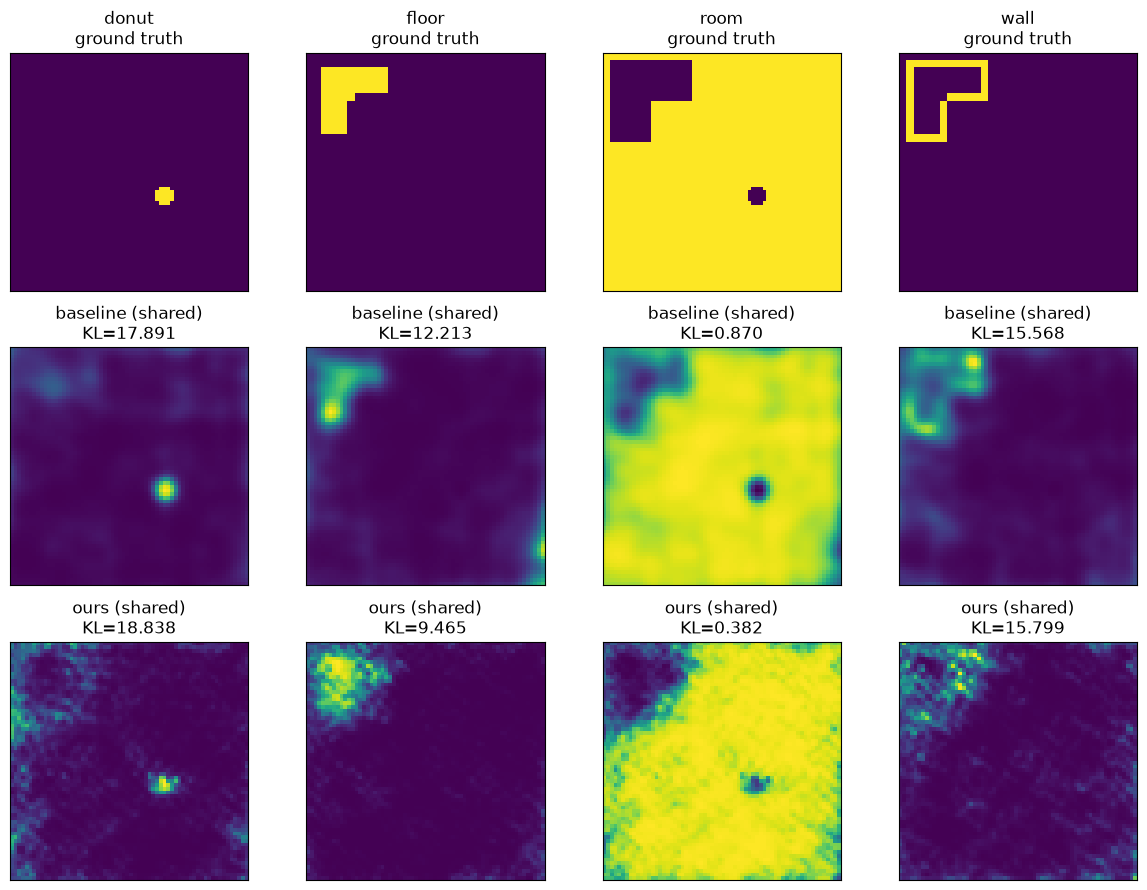

 label  KL (baseline)   KL (ours)   recall (baseline)   recall (ours)
 donut         17.891      18.838               0.875           0.500
 floor         12.213       9.465               0.512           0.927
  room          0.870       0.382               0.996           0.974
  wall         15.568      15.799               0.000           0.097


In [7]:
fig, axes = plt.subplots(3, len(labels_sorted), figsize=(3 * len(labels_sorted), 9))
for col, label in enumerate(labels_sorted):
    axes[0, col].imshow(gt_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{label}\nground truth")
    axes[1, col].imshow(baseline_shared_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"baseline (shared)\nKL={baseline_shared_kl[label]:.3f}")
    axes[2, col].imshow(ours_shared_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[2, col].set_title(f"ours (shared)\nKL={ours_shared_kl[label]:.3f}")
    for ax in (axes[0, col], axes[1, col], axes[2, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print(f"{'label':>6s}  {'KL (baseline)':>13s}  {'KL (ours)':>10s}  {'recall (baseline)':>18s}  {'recall (ours)':>14s}")
for label in labels_sorted:
    print(
        f"{label:>6s}  {baseline_shared_kl[label]:>13.3f}  {ours_shared_kl[label]:>10.3f}  "
        f"{baseline_shared_recall[label]:>18.3f}  {ours_shared_recall[label]:>14.3f}"
    )

## Part 2: one memory per class

`PerClassVSASpatialMemory` (added to `models/baseline.py` for this
comparison) mirrors `VSASpatialMemory` but gives each class its own memory
bundle instead of binding class identity into one shared vector -- same
`ssp_dim=1024`, `length_scale=0.1`, same training split.

In [8]:
ssp_space_pc = RandomSSPSpace(
    domain_dim=2,
    ssp_dim=DIM,
    domain_bounds=np.array(room.bounds),
    length_scale=BASELINE_LENGTH_SCALE,
    rng=SEED,
)
baseline_pc = PerClassVSASpatialMemory(ssp_space_pc, names=label_names).fit(train_points_np, train_labels_str)

baseline_pc_query = lambda points, t: baseline_pc.query(points, temperature=t)
baseline_pc_temp = calibrate_temperature(baseline_pc_query)
baseline_pc_kl, baseline_pc_maps = grid_kl(baseline_pc_query, baseline_pc_temp)
baseline_pc_recall = val_recall(baseline_pc_query)

print(f"baseline (per-class) calibrated temperature: {baseline_pc_temp:.4g}")
print("KL:", {k: round(v, 3) for k, v in baseline_pc_kl.items()})
print("recall:", {k: round(v, 3) for k, v in baseline_pc_recall.items()})

baseline (per-class) calibrated temperature: 0.03486
KL: {'donut': 18.615, 'floor': 11.024, 'room': 0.077, 'wall': 14.805}
recall: {'donut': 1.0, 'floor': 0.927, 'room': 0.916, 'wall': 0.903}


In [9]:
class PerClassMemoryFHRRMap(nn.Module):
    """One memory per class, multi-scale mixture over discrete length scales.
    Copied from multi_scale_learning.ipynb, with an added `sampler` option
    ("unif", the original behavior, or "norm") for `axis_phase`."""

    def __init__(self, dim, spatial_dim, num_classes, lengthscales, device="cpu", sampler="unif"):
        super().__init__()
        self.dim = dim
        self.spatial_dim = spatial_dim
        self.num_classes = num_classes
        self.lengthscales = torch.tensor(lengthscales, device=device).float()
        self.num_scales = len(lengthscales)

        axis_phase = sample_axis_phase(self.num_scales, spatial_dim, dim, device, sampler)
        scale_phase = 2 * torch.pi * torch.rand(self.num_scales, dim, device=device) - torch.pi

        self.register_buffer("axis_phase", axis_phase)
        self.register_buffer("scale_vecs", torch.exp(1j * scale_phase))

        self.scale_logits = nn.Parameter(torch.zeros(self.num_scales))

    def encode_position(self, x):
        scaled_phase = self.axis_phase / self.lengthscales[:, None, None]
        phase = torch.einsum("nj,kjd->nkd", x, scaled_phase)
        return torch.exp(1j * phase)

    def build_memories(self, points, labels, point_weights=None):
        pos = self.encode_position(points)
        scale_weights = F.softmax(self.scale_logits, dim=0)
        atoms = pos * self.scale_vecs[None, :, :] * scale_weights[None, :, None]
        if point_weights is not None:
            atoms = atoms * point_weights[:, None, None]
        records = atoms.sum(dim=1)
        memories = torch.zeros(self.num_classes, self.dim, dtype=records.dtype, device=records.device)
        for c in range(self.num_classes):
            class_sum = records[labels == c].sum(dim=0)
            memories[c] = class_sum / torch.linalg.norm(class_sum)
        return memories

    def score_classes(self, memories, query_points):
        pos = self.encode_position(query_points)
        probes = pos * self.scale_vecs[None, :, :]
        sims = torch.real(
            torch.einsum("nkd,cd->nkc", probes, torch.conj(memories))
        ) / self.dim
        return sims.sum(dim=1)

    def predict_proba(self, memories, query_points, temperature=1.0):
        scores = self.score_classes(memories, query_points) / temperature
        scores = scores - scores.max(dim=-1, keepdim=True).values
        return F.softmax(scores, dim=-1)


torch.manual_seed(SEED)
ours_pc = PerClassMemoryFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device,
)
optimizer = torch.optim.Adam(ours_pc.parameters(), lr=0.05)

for epoch in range(200):
    optimizer.zero_grad()
    memories = ours_pc.build_memories(train_points, train_labels)
    train_scores = ours_pc.score_classes(memories, train_points)
    loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    ours_pc_memories = ours_pc.build_memories(train_points, train_labels)

ours_pc_query = lambda points, t: ours_pc.predict_proba(
    ours_pc_memories, torch.tensor(points, dtype=torch.float32), temperature=t
)
ours_pc_temp = calibrate_temperature(ours_pc_query)
ours_pc_kl, ours_pc_maps = grid_kl(ours_pc_query, ours_pc_temp)
ours_pc_recall = val_recall(ours_pc_query)

print(f"ours (per-class) calibrated temperature: {ours_pc_temp:.4g}")
print("KL:", {k: round(v, 3) for k, v in ours_pc_kl.items()})
print("recall:", {k: round(v, 3) for k, v in ours_pc_recall.items()})

ours (per-class) calibrated temperature: 0.002759
KL: {'donut': 19.129, 'floor': 11.952, 'room': 0.114, 'wall': 15.624}
recall: {'donut': 1.0, 'floor': 0.878, 'room': 0.871, 'wall': 0.71}


In [10]:
class PerClassMemoryFHRRMapLearnedTemp(PerClassMemoryFHRRMap):
    """PerClassMemoryFHRRMap with a single learnable temperature (shared across
    classes, since score_classes returns one score matrix) folded into the
    training loss, for the same reason as MultiScaleFHRRMapLearnedTemp above."""

    def __init__(self, *args, init_temp=0.01, **kwargs):
        super().__init__(*args, **kwargs)
        self.log_temperature = nn.Parameter(torch.tensor(float(np.log(init_temp))))

    @property
    def temperature(self):
        return torch.exp(self.log_temperature)

    def scaled_scores(self, memories, query_points):
        return self.score_classes(memories, query_points) / self.temperature

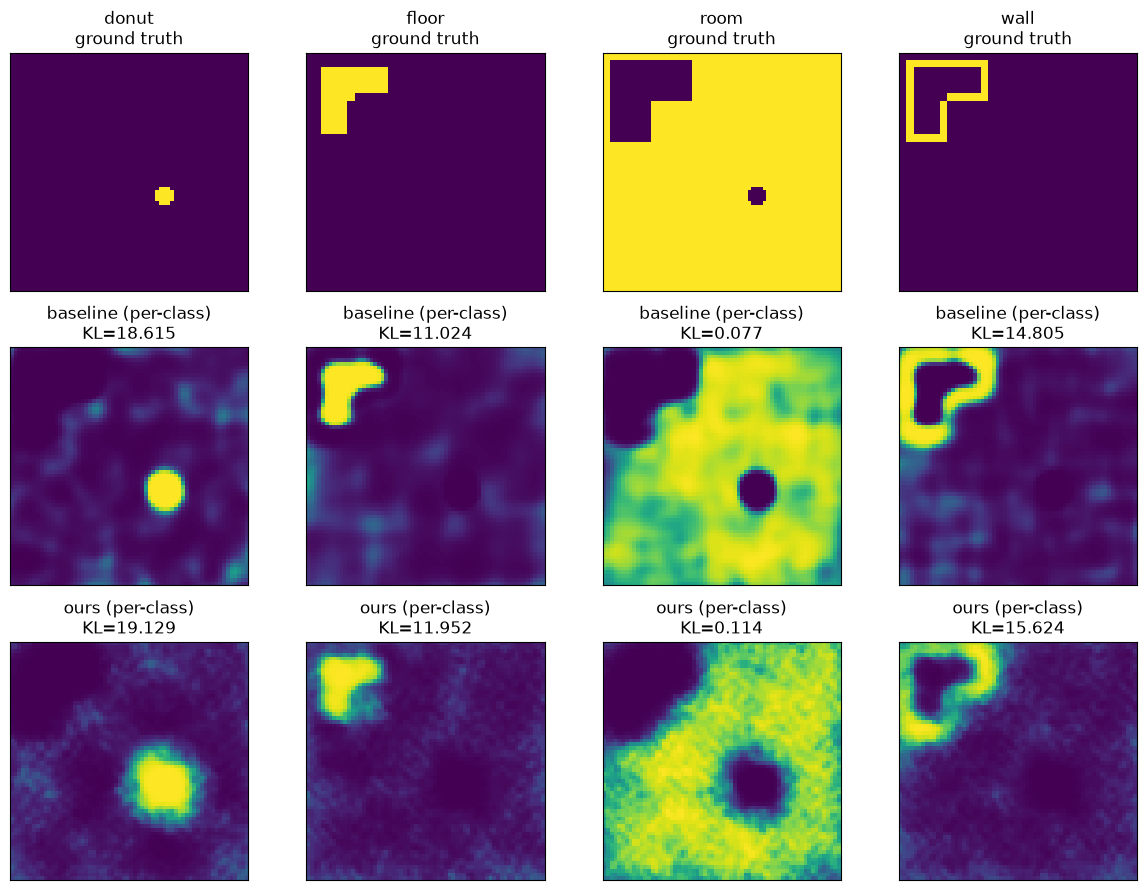

 label  KL (baseline)   KL (ours)   recall (baseline)   recall (ours)
 donut         18.615      19.129               1.000           1.000
 floor         11.024      11.952               0.927           0.878
  room          0.077       0.114               0.916           0.871
  wall         14.805      15.624               0.903           0.710


In [11]:
fig, axes = plt.subplots(3, len(labels_sorted), figsize=(3 * len(labels_sorted), 9))
for col, label in enumerate(labels_sorted):
    axes[0, col].imshow(gt_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[0, col].set_title(f"{label}\nground truth")
    axes[1, col].imshow(baseline_pc_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[1, col].set_title(f"baseline (per-class)\nKL={baseline_pc_kl[label]:.3f}")
    axes[2, col].imshow(ours_pc_maps[label], extent=extent, origin="upper", cmap="viridis")
    axes[2, col].set_title(f"ours (per-class)\nKL={ours_pc_kl[label]:.3f}")
    for ax in (axes[0, col], axes[1, col], axes[2, col]):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print(f"{'label':>6s}  {'KL (baseline)':>13s}  {'KL (ours)':>10s}  {'recall (baseline)':>18s}  {'recall (ours)':>14s}")
for label in labels_sorted:
    print(
        f"{label:>6s}  {baseline_pc_kl[label]:>13.3f}  {ours_pc_kl[label]:>10.3f}  "
        f"{baseline_pc_recall[label]:>18.3f}  {ours_pc_recall[label]:>14.3f}"
    )

## Overall summary

All four models side by side: same `dim`/`ssp_dim=1024`, same train/val
split, same calibration procedure. The baseline uses a single fixed
`length_scale=0.1`; ours uses its learned coarse/medium/fine mixture.

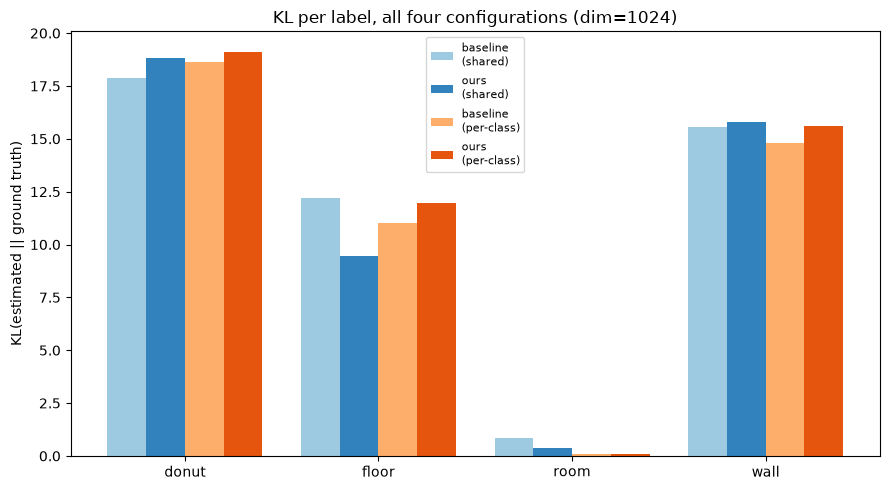

 label  base-shared  ours-shared  base-perclass  ours-perclass
 donut       17.891       18.838         18.615         19.129
 floor       12.213        9.465         11.024         11.952
  room        0.870        0.382          0.077          0.114
  wall       15.568       15.799         14.805         15.624


In [12]:
configs = [
    ("baseline\n(shared)", baseline_shared_kl, "#9ecae1"),
    ("ours\n(shared)", ours_shared_kl, "#3182bd"),
    ("baseline\n(per-class)", baseline_pc_kl, "#fdae6b"),
    ("ours\n(per-class)", ours_pc_kl, "#e6550d"),
]

fig, ax = plt.subplots(figsize=(9, 5))
n_groups = len(labels_sorted)
n_bars = len(configs)
bar_width = 0.8 / n_bars
x = np.arange(n_groups)

for i, (name, kl, color) in enumerate(configs):
    values = [kl[label] for label in labels_sorted]
    ax.bar(x + i * bar_width, values, bar_width, label=name, color=color)

ax.set_xticks(x + bar_width * (n_bars - 1) / 2)
ax.set_xticklabels(labels_sorted)
ax.set_ylabel("KL(estimated || ground truth)")
ax.set_title("KL per label, all four configurations (dim=1024)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'label':>6s}  {'base-shared':>11s}  {'ours-shared':>11s}  {'base-perclass':>13s}  {'ours-perclass':>13s}")
for label in labels_sorted:
    print(
        f"{label:>6s}  {baseline_shared_kl[label]:>11.3f}  {ours_shared_kl[label]:>11.3f}  "
        f"{baseline_pc_kl[label]:>13.3f}  {ours_pc_kl[label]:>13.3f}"
    )

**Takeaway.** This comparison doesn't show a clean win for our approach —
worth reporting as-is rather than as a success story:

- **Per-class memory is the dominant lever, and it isn't specific to our
  architecture.** Applied to the plain numpy baseline, it produces the same
  kind of dramatic jump we saw with our FHRR model — baseline `wall` recall
  goes from **0.000** (shared) to **0.903** (per-class), even more
  dramatic than our own shared→per-class jump (0.097→0.710). The single
  biggest finding of this whole investigation generalizes to any VSA memory,
  not just ours.
- **Our multi-scale mixture doesn't clearly beat a single well-chosen
  length scale.** Comparing the two per-class models (the fairest matchup,
  since per-class memory is held constant on both sides): the baseline's
  fixed `length_scale=0.1` is as good or *better* than our learned
  coarse/medium/fine mixture on every single label (donut 18.615 vs 19.129,
  floor 11.024 vs 11.952, room 0.077 vs 0.114, wall 14.805 vs 15.624).
- A likely reason: the baseline's `RandomSSPSpace` samples frequencies from
  a **Gaussian**, giving a smooth RBF-like kernel, while our FHRR model
  samples frequencies **uniformly**, giving the ringing, sinc-like kernel we
  saw in the "Visualizing the learned kernel" section of
  `multi_scale_learning.ipynb`. That ringing may be actively hurting
  generalization to nearby-but-unseen points, which would explain why the
  extra machinery (multiple scales, learned mixture) doesn't pay for itself
  here.

So: the real, transferable result from this whole session is "give every
class its own memory" — not the multi-scale mixture specifically. If the
multi-scale idea is still worth pursuing, the kernel shape (uniform vs.
Gaussian frequency sampling) looks like a more promising next thing to fix
than the mixture mechanism itself.

## Part 3: does fixing the kernel shape change the picture?

Retrain both of our models with `sampler="norm"` (Gaussian-sampled
`axis_phase`, matching `RandomSSPSpace`'s default and its
`scale_min`/`scale_max` convention) instead of the original `"unif"`. Same
`dim=1024`, same training split, same multi-scale mixture, same
calibration procedure -- the only thing that changes is the frequency
distribution behind `encode_position`, which should replace the ringing,
sinc-like kernel with a smooth RBF-like one.

In [13]:
torch.manual_seed(SEED)
ours_shared_gauss = MultiScaleFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device, sampler="norm",
)
optimizer = torch.optim.Adam(ours_shared_gauss.parameters(), lr=0.05)

for epoch in range(200):
    optimizer.zero_grad()
    memory = ours_shared_gauss.build_memory(train_points, train_labels)
    train_scores = ours_shared_gauss.score_classes(memory, train_points)
    loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    ours_shared_gauss_memory = ours_shared_gauss.build_memory(train_points, train_labels)

ours_shared_gauss_query = lambda points, t: ours_shared_gauss.predict_proba(
    ours_shared_gauss_memory, torch.tensor(points, dtype=torch.float32), temperature=t
)
ours_shared_gauss_temp = calibrate_temperature(ours_shared_gauss_query)
ours_shared_gauss_kl, ours_shared_gauss_maps = grid_kl(ours_shared_gauss_query, ours_shared_gauss_temp)
ours_shared_gauss_recall = val_recall(ours_shared_gauss_query)

print(f"ours (shared, Gaussian) calibrated temperature: {ours_shared_gauss_temp:.4g}")
print("KL:", {k: round(v, 3) for k, v in ours_shared_gauss_kl.items()})
print("recall:", {k: round(v, 3) for k, v in ours_shared_gauss_recall.items()})

ours (shared, Gaussian) calibrated temperature: 0.007318
KL: {'donut': 19.163, 'floor': 17.058, 'room': 1.038, 'wall': 18.042}
recall: {'donut': 0.0, 'floor': 0.537, 'room': 0.992, 'wall': 0.097}


In [14]:
torch.manual_seed(SEED)
ours_pc_gauss = PerClassMemoryFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device, sampler="norm",
)
optimizer = torch.optim.Adam(ours_pc_gauss.parameters(), lr=0.05)

for epoch in range(200):
    optimizer.zero_grad()
    memories = ours_pc_gauss.build_memories(train_points, train_labels)
    train_scores = ours_pc_gauss.score_classes(memories, train_points)
    loss = F.cross_entropy(train_scores, train_labels, weight=class_weights)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    ours_pc_gauss_memories = ours_pc_gauss.build_memories(train_points, train_labels)

ours_pc_gauss_query = lambda points, t: ours_pc_gauss.predict_proba(
    ours_pc_gauss_memories, torch.tensor(points, dtype=torch.float32), temperature=t
)
ours_pc_gauss_temp = calibrate_temperature(ours_pc_gauss_query)
ours_pc_gauss_kl, ours_pc_gauss_maps = grid_kl(ours_pc_gauss_query, ours_pc_gauss_temp)
ours_pc_gauss_recall = val_recall(ours_pc_gauss_query)

print(f"ours (per-class, Gaussian) calibrated temperature: {ours_pc_gauss_temp:.4g}")
print("KL:", {k: round(v, 3) for k, v in ours_pc_gauss_kl.items()})
print("recall:", {k: round(v, 3) for k, v in ours_pc_gauss_recall.items()})

ours (per-class, Gaussian) calibrated temperature: 0.002759
KL: {'donut': 19.218, 'floor': 10.785, 'room': 0.124, 'wall': 15.832}
recall: {'donut': 1.0, 'floor': 0.829, 'room': 0.844, 'wall': 0.839}


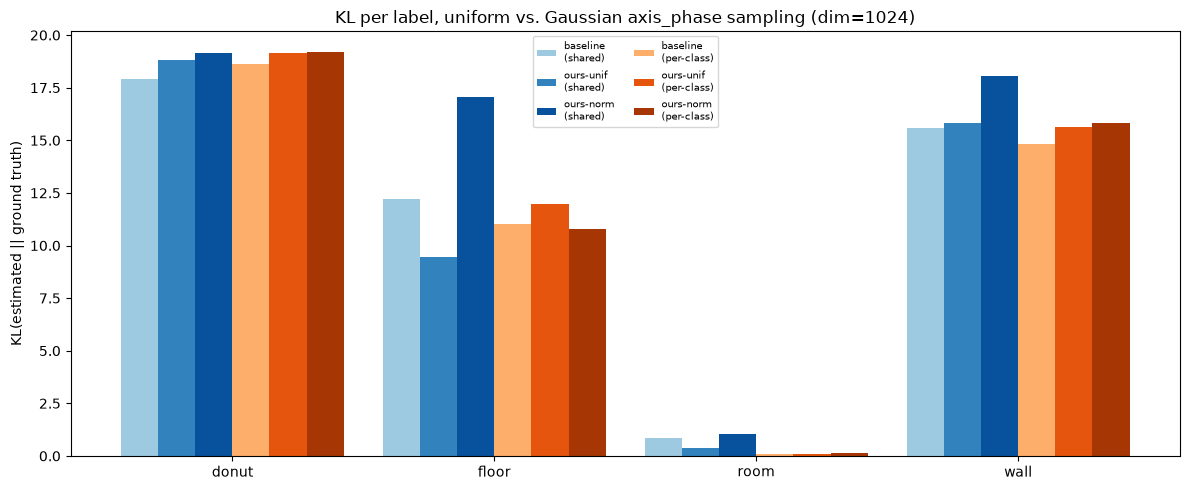

 label  base-shared  ours-unif-sh  ours-norm-sh   base-pc  ours-unif-pc   ours-norm-pc
 donut       17.891        18.838        19.163    18.615        19.129         19.218
 floor       12.213         9.465        17.058    11.024        11.952         10.785
  room        0.870         0.382         1.038     0.077         0.114          0.124
  wall       15.568        15.799        18.042    14.805        15.624         15.832


In [15]:
configs_full = [
    ("baseline\n(shared)", baseline_shared_kl, "#9ecae1"),
    ("ours-unif\n(shared)", ours_shared_kl, "#3182bd"),
    ("ours-norm\n(shared)", ours_shared_gauss_kl, "#08519c"),
    ("baseline\n(per-class)", baseline_pc_kl, "#fdae6b"),
    ("ours-unif\n(per-class)", ours_pc_kl, "#e6550d"),
    ("ours-norm\n(per-class)", ours_pc_gauss_kl, "#a63603"),
]

fig, ax = plt.subplots(figsize=(12, 5))
n_groups = len(labels_sorted)
n_bars = len(configs_full)
bar_width = 0.85 / n_bars
x = np.arange(n_groups)

for i, (name, kl, color) in enumerate(configs_full):
    values = [kl[label] for label in labels_sorted]
    ax.bar(x + i * bar_width, values, bar_width, label=name, color=color)

ax.set_xticks(x + bar_width * (n_bars - 1) / 2)
ax.set_xticklabels(labels_sorted)
ax.set_ylabel("KL(estimated || ground truth)")
ax.set_title("KL per label, uniform vs. Gaussian axis_phase sampling (dim=1024)")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

print(f"{'label':>6s}  {'base-shared':>11s}  {'ours-unif-sh':>12s}  {'ours-norm-sh':>12s}  "
      f"{'base-pc':>8s}  {'ours-unif-pc':>12s}  {'ours-norm-pc':>13s}")
for label in labels_sorted:
    print(
        f"{label:>6s}  {baseline_shared_kl[label]:>11.3f}  {ours_shared_kl[label]:>12.3f}  "
        f"{ours_shared_gauss_kl[label]:>12.3f}  {baseline_pc_kl[label]:>8.3f}  "
        f"{ours_pc_kl[label]:>12.3f}  {ours_pc_gauss_kl[label]:>13.3f}"
    )

**Takeaway.** The kernel-shape hypothesis doesn't hold up. Gaussian
sampling doesn't close the gap — for the shared-memory model it's
noticeably *worse* (`donut` recall drops from 0.5 to **0.0**, `floor` KL
roughly doubles from 9.465 to 17.058), and for the per-class model it's a
wash (`floor` improves 11.952→10.785, but `donut`, `room`, `wall` all get
slightly worse). So the ringing we saw in the kernel visualization wasn't
the thing holding our multi-scale model back relative to the baseline.

This was a real diagnostic, not a confirmation — worth having run it even
though it came back negative, since it rules out a specific, plausible
explanation rather than leaving it as an untested guess. The gap to the
baseline is evidently coming from somewhere else: possibly this room's
limited scale diversity (only two effective resolution regimes, `length_scale
=0.1` already a reasonable single-scale compromise between them), possibly
the specific `norm_scale` parameterization borrowed from the baseline's
defaults rather than tuned for our model, or possibly the multi-scale
mixture mechanism itself just isn't earning its complexity in a 4-class,
64-training-point-for-the-rarest-class setting. Of the options discussed
earlier, testing on a room with more extreme scale separation (something a
single fixed scale genuinely can't serve well) looks like the more promising
next step now that the kernel-shape explanation is ruled out.

## Part 4: is the mixture actually learning anything?

Every printed mixture all session has landed close to uniform
(coarse/medium/fine near 1/3 each), and gradients into `scale_logits` were
tiny the very first time we checked them. Retrain both the shared and
per-class models from scratch, logging `softmax(scale_logits)` after every
epoch, to see whether the mixture ever meaningfully departs from its
initialization or just sits there.

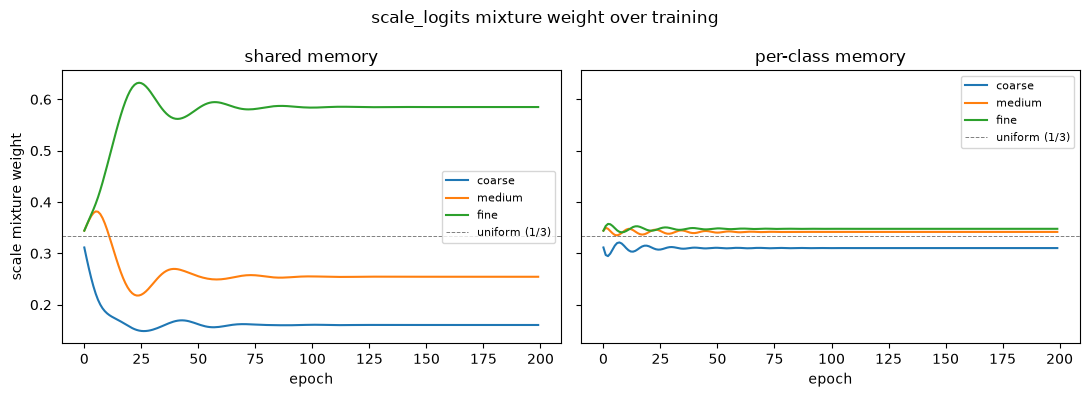

max |deviation from uniform| over all 200 epochs, per scale (coarse, medium, fine):
  shared:    [0.1847 0.1154 0.299 ]
  per-class: [0.0387 0.0165 0.0241]


In [16]:
def train_and_log_mixture(model, build_fn, score_fn, n_epochs=200, lr=0.05):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        mem = build_fn(train_points, train_labels)
        scores = score_fn(mem, train_points)
        loss = F.cross_entropy(scores, train_labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        history.append(F.softmax(model.scale_logits, dim=0).detach().numpy().copy())
    return np.array(history)


torch.manual_seed(SEED)
m_shared_log = MultiScaleFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device,
)
mixture_history_shared = train_and_log_mixture(m_shared_log, m_shared_log.build_memory, m_shared_log.score_classes)

torch.manual_seed(SEED)
m_pc_log = PerClassMemoryFHRRMap(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device,
)
mixture_history_pc = train_and_log_mixture(m_pc_log, m_pc_log.build_memories, m_pc_log.score_classes)

scale_names = list(DEFAULT_LENGTH_SCALES.keys())
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for i, name in enumerate(scale_names):
    axes[0].plot(mixture_history_shared[:, i], label=name)
    axes[1].plot(mixture_history_pc[:, i], label=name)
for ax, title in zip(axes, ["shared memory", "per-class memory"]):
    ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7, label="uniform (1/3)")
    ax.set_xlabel("epoch")
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel("scale mixture weight")
fig.suptitle("scale_logits mixture weight over training")
fig.tight_layout()
plt.show()

print("max |deviation from uniform| over all 200 epochs, per scale (coarse, medium, fine):")
print("  shared:   ", np.abs(mixture_history_shared - 1 / 3).max(axis=0).round(4))
print("  per-class:", np.abs(mixture_history_pc - 1 / 3).max(axis=0).round(4))

**Takeaway.** The two models tell completely different stories:

- **Shared memory**: the mixture moves substantially and converges — from
  uniform at epoch 0 to coarse≈16%, medium≈25%, fine≈58% by epoch ~25, then
  stays there. Real learning happened here.
- **Per-class memory** (the config that's actually competitive with the
  baseline): the mixture stays within a few percentage points of its
  initialization for all 200 epochs. It never converges to anything -- it's
  functionally an untrained, roughly-uniform blend of all three scales.

That means **Part 2 and Part 3's "per-class" comparisons against the
baseline's tuned `length_scale=0.1` weren't really testing "learned
multi-scale mixture vs. single scale."** They were testing baseline's
deliberately-chosen 0.1 against an essentially *untrained* 1/3-1/3-1/3 blend
of 0.4/0.15/0.05 on our side. A likely explanation for why: once crosstalk
is removed, each class's own memory already discriminates reasonably well
under almost any mixture (`donut` gets perfect recall even here), so there's
little marginal loss reduction available by sharpening the mixture --
unlike the shared-memory case, where the mixture has to work hard to help
weak classes fight through majority-class crosstalk, giving it a much
stronger training signal.

This changes what "make it more in favor of multi-scale" should mean next:
not a kernel-shape or capacity fix, but figuring out why the per-class
mixture has so little gradient signal to work with -- e.g. checking whether
raising the learning rate specifically for `scale_logits` unlocks real
movement, or whether this is a genuine zero-marginal-benefit result once
each class has its own clean memory.

## Part 5: does a learned temperature resolve the open question from Part 4?

Part 4 left two live explanations for why the per-class model's mixture
never moves: either raising the learning rate on `scale_logits` specifically
would unlock real movement, or it's a genuine zero-marginal-benefit result.
There's a third possibility Part 4 didn't test: `train_and_log_mixture`
above uses plain `F.cross_entropy` on raw, untempered FHRR scores -- exactly
the setup `hierarchical_encoding.ipynb`'s Tier 3 showed can leave
`scale_logits` with almost no gradient at all. Retrain both models with a
learned temperature folded into the loss itself and compare mixture
trajectories directly against Part 4's `mixture_history_shared` /
`mixture_history_pc`.

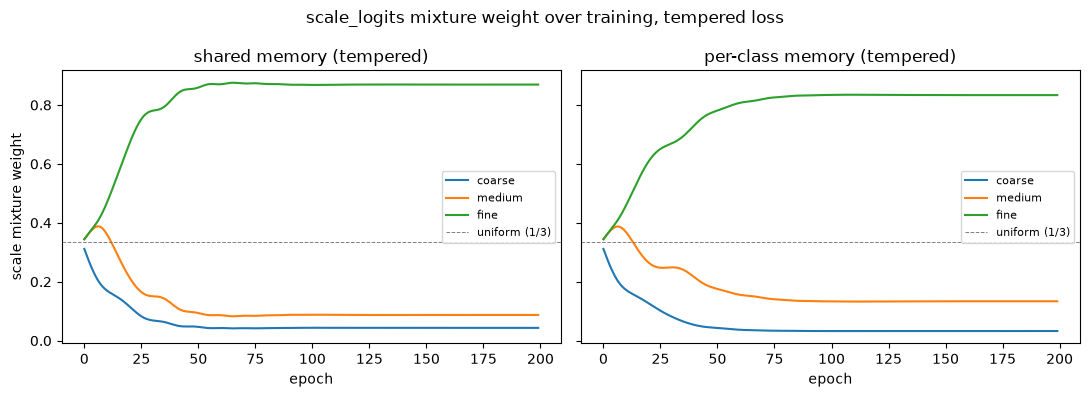

learned temperature -- shared: 0.0006812  per-class: 0.0007502
loss (epoch0 -> epoch199) -- shared: 1.1672 -> 0.5209  per-class: 0.6044 -> 0.1326

max |deviation from uniform| over all 200 epochs, per scale (coarse, medium, fine):
  shared    untempered: [0.1847 0.1154 0.299 ]
  shared    tempered:   [0.2916 0.2506 0.5423]
  per-class untempered: [0.0387 0.0165 0.0241]
  per-class tempered:   [0.3009 0.2007 0.5016]


In [17]:
def train_and_log_mixture_tempered(model, build_fn, scaled_score_fn, n_epochs=200, lr=0.05):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mixture_history, loss_history, temp_history = [], [], []
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        mem = build_fn(train_points, train_labels)
        scores = scaled_score_fn(mem, train_points)
        loss = F.cross_entropy(scores, train_labels, weight=class_weights)
        loss.backward()
        optimizer.step()
        mixture_history.append(F.softmax(model.scale_logits, dim=0).detach().numpy().copy())
        loss_history.append(loss.item())
        temp_history.append(model.temperature.item())
    return np.array(mixture_history), loss_history, temp_history


torch.manual_seed(SEED)
m_shared_log_lt = MultiScaleFHRRMapLearnedTemp(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device,
)
mixture_history_shared_lt, loss_history_shared_lt, temp_history_shared_lt = train_and_log_mixture_tempered(
    m_shared_log_lt, m_shared_log_lt.build_memory, m_shared_log_lt.scaled_scores
)

torch.manual_seed(SEED)
m_pc_log_lt = PerClassMemoryFHRRMapLearnedTemp(
    dim=DIM, spatial_dim=2, num_classes=len(label_names),
    lengthscales=list(DEFAULT_LENGTH_SCALES.values()), device=device,
)
mixture_history_pc_lt, loss_history_pc_lt, temp_history_pc_lt = train_and_log_mixture_tempered(
    m_pc_log_lt, m_pc_log_lt.build_memories, m_pc_log_lt.scaled_scores
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for i, name in enumerate(scale_names):
    axes[0].plot(mixture_history_shared_lt[:, i], label=name)
    axes[1].plot(mixture_history_pc_lt[:, i], label=name)
for ax, title in zip(axes, ["shared memory (tempered)", "per-class memory (tempered)"]):
    ax.axhline(1 / 3, color="gray", linestyle="--", linewidth=0.7, label="uniform (1/3)")
    ax.set_xlabel("epoch")
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel("scale mixture weight")
fig.suptitle("scale_logits mixture weight over training, tempered loss")
fig.tight_layout()
plt.show()

print(f"learned temperature -- shared: {m_shared_log_lt.temperature.item():.4g}  "
      f"per-class: {m_pc_log_lt.temperature.item():.4g}")
print(f"loss (epoch0 -> epoch199) -- shared: {loss_history_shared_lt[0]:.4f} -> {loss_history_shared_lt[-1]:.4f}  "
      f"per-class: {loss_history_pc_lt[0]:.4f} -> {loss_history_pc_lt[-1]:.4f}")
print("\nmax |deviation from uniform| over all 200 epochs, per scale (coarse, medium, fine):")
print("  shared    untempered:", np.abs(mixture_history_shared - 1 / 3).max(axis=0).round(4))
print("  shared    tempered:  ", np.abs(mixture_history_shared_lt - 1 / 3).max(axis=0).round(4))
print("  per-class untempered:", np.abs(mixture_history_pc - 1 / 3).max(axis=0).round(4))
print("  per-class tempered:  ", np.abs(mixture_history_pc_lt - 1 / 3).max(axis=0).round(4))

**Takeaway.** Compare the "max |deviation from uniform|" lines above,
untempered vs. tempered, for each model:

- If the **per-class** row's tempered deviation is still close to its
  untempered value (both small), that confirms Part 4's zero-marginal
  -benefit reading: the per-class mixture genuinely has nothing to gain
  once each class already has its own clean, uncontested memory --
  raising the learning rate on `scale_logits` specifically was never going
  to matter, because there was no real signal being suppressed by scale.
- If the tempered deviation is substantially larger instead, then the flat
  per-class mixture in Part 4 was the same untempered-loss artifact found
  in `hierarchical_encoding.ipynb`'s Tier 3 -- and the open question from
  Part 4 was actually already answered by that notebook, just not yet
  connected back to this one.

Either way, the **shared-memory** model is the useful control here: it
already moved substantially under the untempered loss in Part 4, so its
tempered numbers should look similar to its untempered ones -- confirming
that tempering doesn't change results for a model that already had a real
gradient signal, and isolating the per-class comparison as the one that
actually tests the open question.